In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from collections import Counter

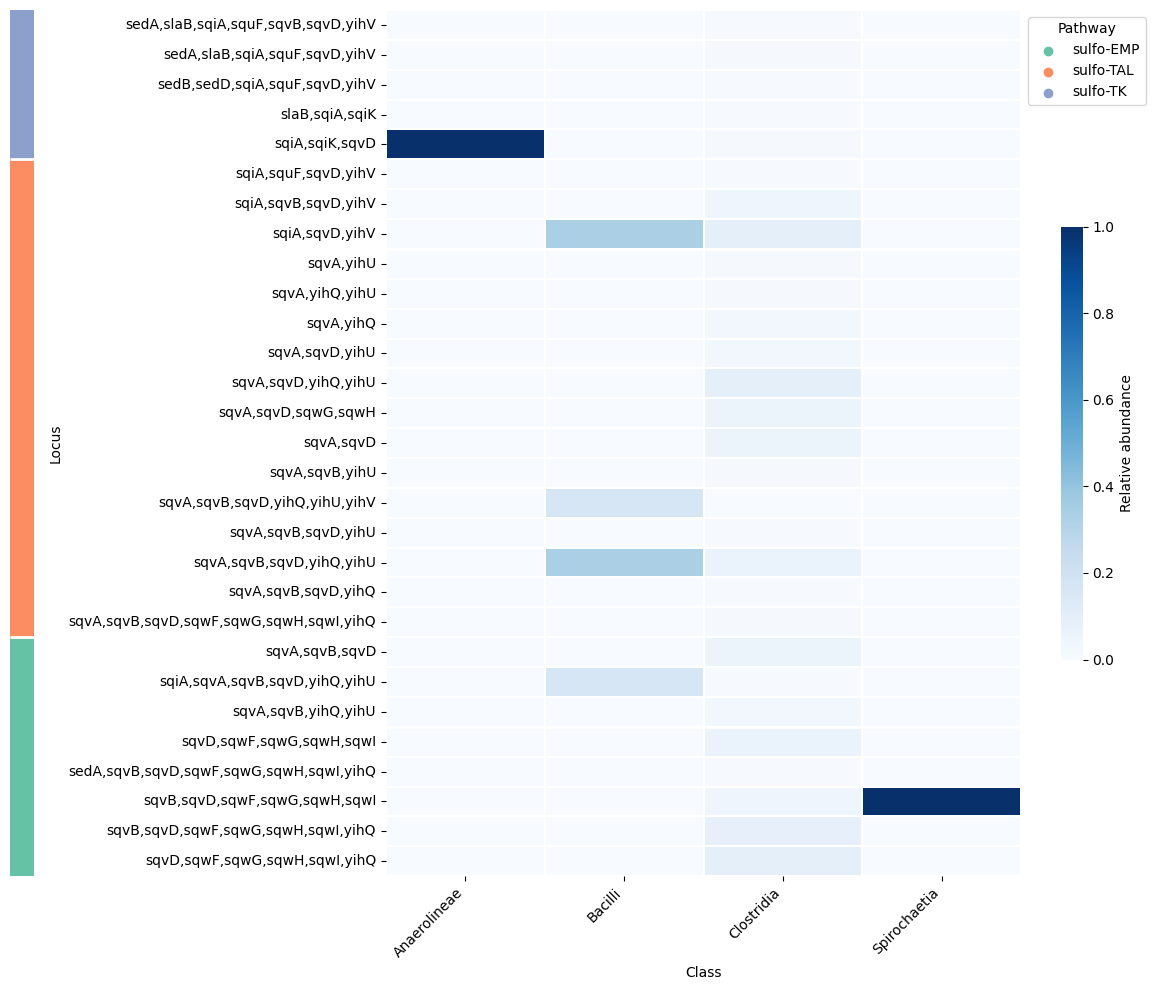

<Figure size 640x480 with 0 Axes>

In [ ]:
# --- загрузка ---
df = pd.read_csv("../data/final_table.csv")

# --- фильтрация ---
df_filtered = df[df["SQ_score"].isin(["min_up", "min_down", "max"])].copy()

# --- извлекаем класс ---
df_filtered["class"] = df_filtered["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("c__")][0].replace("c__", "")
)

# --- нормализуем локус (сортировка генов) ---
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# --- pathway для каждого локуса ---
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

# --- считаем raw counts: locus × class ---
heatmap_df = (
    df_filtered
    .groupby(["locus", "class"])
    .size()
    .unstack(fill_value=0)
)

# нормируем по числу геномов в каждом классе
class_sizes = df_filtered.groupby("class").size()

heatmap_norm = heatmap_df.div(class_sizes, axis=1)

# --- добавляем pathway ---
heatmap_norm["pathway"] = heatmap_norm.index.map(locus_pathway)

# --- сортировка по pathway ---
heatmap_norm = heatmap_norm.sort_values("pathway")

# --- отделяем мета-инфо ---
pathway_labels = heatmap_norm["pathway"]
heatmap_norm = heatmap_norm.drop(columns="pathway")

# --- заполнение возможных NaN ---
heatmap_norm = heatmap_norm.fillna(0)
# --- 7. Цвета для pathway ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))

pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- 8. Создаём фигуру с двумя осями (аннотация + heatmap) ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- 9. Рисуем цветовую полосу pathway ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- 10. Heatmap ---
sns.heatmap(
    heatmap_norm,
    cmap="Blues",
    ax=ax,
    cbar_kws={
        "label": "Relative abundance",
        "shrink": 0.5,      # уменьшает длину colorbar
        "aspect": 20        # делает его тоньше
    },
    linewidths=0.2
)

# --- 11. Разделители между pathway ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- 12. Подписи ---
ax.set_xlabel("Class")
ax.set_ylabel("Locus")

ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


# --- 13. Легенда pathway ---
for pathway, color in pathway_colors.items():
    ax.scatter([], [], color=color, label=pathway)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),  # немного сдвигаем вправо
    loc='upper left'
)
plt.tight_layout()
plt.show()
plt.savefig("../pictures/loci/loci_among_classes_norm.png", dpi=300) 

In [ ]:
# --- locus ---
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# --- pathway на locus ---
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

# --- raw counts ---
heatmap_df = (
    df_filtered
    .groupby(["locus", "class"])
    .size()
    .unstack(fill_value=0)
)

# --- сортировка классов по общей численности (ВАЖНО для доминирования) ---
class_order = heatmap_df.sum(axis=0).sort_values(ascending=False).index
heatmap_df = heatmap_df[class_order]

# --- сортировка локусов по pathway ---
heatmap_df["pathway"] = heatmap_df.index.map(locus_pathway)
heatmap_df = heatmap_df.sort_values("pathway")

pathway_labels = heatmap_df["pathway"]
heatmap_df = heatmap_df.drop(columns="pathway")

# --- лог-преобразование (чтобы не “убивалось” всё доминирование) ---
heatmap_plot = np.log1p(heatmap_df)

In [ ]:
# --- 7. Цвета для pathway ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))

pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- 8. Создаём фигуру с двумя осями (аннотация + heatmap) ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- 9. Рисуем цветовую полосу pathway ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- 10. Heatmap ---
sns.heatmap(
    heatmap_plot,
    cmap="Blues",
    ax=ax,
    cbar_kws={
        "label": "Relative abundance",
        "shrink": 0.5,      # уменьшает длину colorbar
        "aspect": 20        # делает его тоньше
    },
    linewidths=0.2
)

# --- 11. Разделители между pathway ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- 12. Подписи ---
ax.set_xlabel("Class")
ax.set_ylabel("Locus")

ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


# --- 13. Легенда pathway ---
for pathway, color in pathway_colors.items():
    ax.scatter([], [], color=color, label=pathway)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),  # немного сдвигаем вправо
    loc='upper left'
)
plt.tight_layout()
plt.show()
plt.savefig("../pictures/loci/loci_among_classes_log.png", dpi=300) 

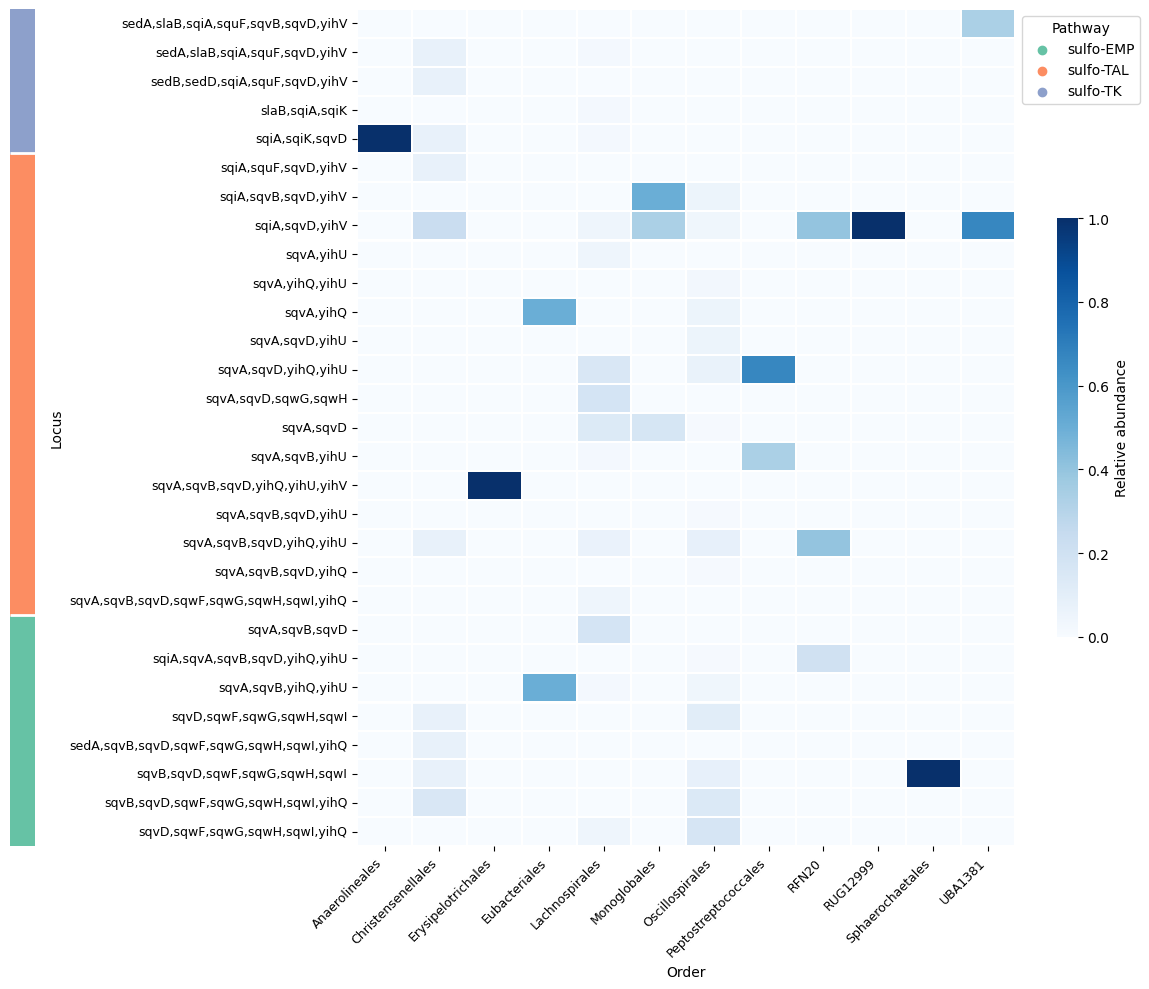

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- загрузка ---
df = pd.read_csv("../data/final_table.csv")

# --- фильтрация ---
df_filtered = df[df["SQ_score"].isin(["min_up", "min_down", "max"])].copy()

# --- извлекаем ORDER ---
df_filtered["order"] = df_filtered["taxonomy"].apply(
    lambda x: [t for t in x.split(";") if t.startswith("o__")][0].replace("o__", "")
)

# --- locus (стабильный ID генного набора) ---
df_filtered["locus"] = df_filtered["SQ_gene_content_set"].apply(
    lambda x: ",".join(sorted(x.split(",")))
)

# --- pathway на уровне locus ---
locus_pathway = (
    df_filtered
    .groupby("locus")["SQ_pathway"]
    .agg(lambda x: x.mode()[0])
)

# --- RAW counts: locus × order ---
heatmap_df = (
    df_filtered
    .groupby(["locus", "order"])
    .size()
    .unstack(fill_value=0)
)

# --- нормализация по размерам orders ---
order_sizes = df_filtered.groupby("order").size()
heatmap_norm = heatmap_df.div(order_sizes, axis=1)

# --- добавляем pathway ---
heatmap_norm["pathway"] = heatmap_norm.index.map(locus_pathway)

# --- сортировка по pathway ---
heatmap_norm = heatmap_norm.sort_values("pathway")

# --- отделяем мета-инфо ---
pathway_labels = heatmap_norm["pathway"]
heatmap_norm = heatmap_norm.drop(columns="pathway").fillna(0)

# =========================
# VISUALIZATION
# =========================

# --- цвета pathway ---
pathway_unique = pathway_labels.unique()
palette = sns.color_palette("Set2", len(pathway_unique))
pathway_colors = dict(zip(pathway_unique, palette))
row_colors = pathway_labels.map(pathway_colors)

# --- фигура ---
fig, (ax_color, ax) = plt.subplots(
    ncols=2,
    figsize=(12, 10),
    gridspec_kw={"width_ratios": [0.3, 10]}
)

# --- sidebar ---
for i, color in enumerate(row_colors):
    ax_color.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

ax_color.set_xlim(0, 1)
ax_color.set_ylim(0, len(row_colors))
ax_color.axis("off")

# --- heatmap ---
sns.heatmap(
    heatmap_norm,
    cmap="Blues",
    ax=ax,
    linewidths=0.2,
    cbar_kws={
        "label": "Relative abundance",
        "shrink": 0.5,
        "aspect": 20
    }
)

# --- boundaries (pathway blocks) ---
boundaries = []
prev = pathway_labels.iloc[0]

for i, val in enumerate(pathway_labels):
    if val != prev:
        boundaries.append(i)
        prev = val

for b in boundaries:
    ax.hlines(b, *ax.get_xlim(), colors='white', linewidth=2)
    ax_color.hlines(b, *ax_color.get_xlim(), colors='white', linewidth=2)

# --- labels ---
ax.set_xlabel("Order")
ax.set_ylabel("Locus")

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

# --- legend ---
for p, c in pathway_colors.items():
    ax.scatter([], [], color=c, label=p)

ax.legend(
    title="Pathway",
    bbox_to_anchor=(1, 1),
    loc="upper left"
)

plt.tight_layout()

# --- save BEFORE show ---
plt.savefig(
    "../pictures/loci/loci_among_orders_norm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()